문제1문제 1. 게임 아이템 뽑기 확률, 정말 10%일까?

In [6]:
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 10.7 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 11.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 10.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmode

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [7]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

1-1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.

귀무가설 H₀: p = 0.10 (개발사 주장이 맞다)

대립가설 H₁: p < 0.10 (실제 확률이 더 낮다)

1-2. 이항검정을 수행하고 p-값을 계산해봅시다.

In [1]:
from scipy import stats

n = 200      # 총 시행 횟수
x = 12       # 성공 횟수
p0 = 0.10    # 개발사가 주장하는 확률 (귀무가설)

# 대립가설 H1: p < 0.10 (실제 확률이 더 낮다)
result = stats.binomtest(x, n, p0, alternative='less')

print(f"관측 비율: {x/n:.3f}")
print(f"p-value: {result.pvalue:.5f}")

if result.pvalue < 0.05:
    print("→ 귀무가설 기각: 실제 확률이 10%보다 낮다고 볼 수 있다 (유의수준 5% 기준)")
else:
    print("→ 귀무가설 채택 실패: 10%보다 낮다고 볼 충분한 근거 없음")

관측 비율: 0.060
p-value: 0.03205
→ 귀무가설 기각: 실제 확률이 10%보다 낮다고 볼 수 있다 (유의수준 5% 기준)


1-3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.

In [3]:
from scipy import stats

n = 200      # 총 시행 횟수
x = 12       # 성공 횟수
p0 = 0.10    # 개발사가 주장하는 확률 (귀무가설)
alpha = 0.05 # 유의수준

# 이항검정 수행 (H1: p < 0.10)
result = stats.binomtest(x, n, p0, alternative='less')
p_value = result.pvalue

print(f"관측 비율: {x/n:.3f}")
print(f"p-value: {p_value:.5f}")
print(f"유의수준(alpha): {alpha}")

# 통계적 결론 도출
if p_value < alpha:
    print("결론: p-value < alpha → 귀무가설(H0: p=0.10)을 기각한다.")
    print("→ 실제 뽑기 확률이 10%보다 낮다고 통계적으로 유의미하게 판단된다.")
else:
    print("결론: p-value >= alpha → 귀무가설을 기각할 수 없다.")
    print("→ 실제 확률이 10%보다 낮다고 볼 충분한 통계적 근거가 없다.")

관측 비율: 0.060
p-value: 0.03205
유의수준(alpha): 0.05
결론: p-value < alpha → 귀무가설(H0: p=0.10)을 기각한다.
→ 실제 뽑기 확률이 10%보다 낮다고 통계적으로 유의미하게 판단된다.


1-4. H₀가 사실(실제 확률 = 10%)이라고 가정하고, 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.

In [4]:
import numpy as np

np.random.seed(42)   # 재현성을 위한 시드 고정

n = 200        # 한 번의 실험에서 뽑는 횟수
p0 = 0.10      # H0가 참이라고 가정한 확률 (개발사 주장)
n_sim = 10000  # 반복 횟수

# H0가 사실이라고 가정하고, 200번 뽑기를 10,000번 반복 시뮬레이션
simulated_successes = np.random.binomial(n=n, p=p0, size=n_sim)

print("시뮬레이션 결과 앞부분 10개:", simulated_successes[:10])
print(f"평균 성공 횟수: {simulated_successes.mean():.2f} (이론값: {n*p0})")
print(f"표준편차: {simulated_successes.std():.2f}")

시뮬레이션 결과 앞부분 10개: [19 27 23 21 16 16 14 25 21 22]
평균 성공 횟수: 19.91 (이론값: 20.0)
표준편차: 4.21


1-5. 시뮬레이션 결과를 히스토그램으로 그려봅시다. 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

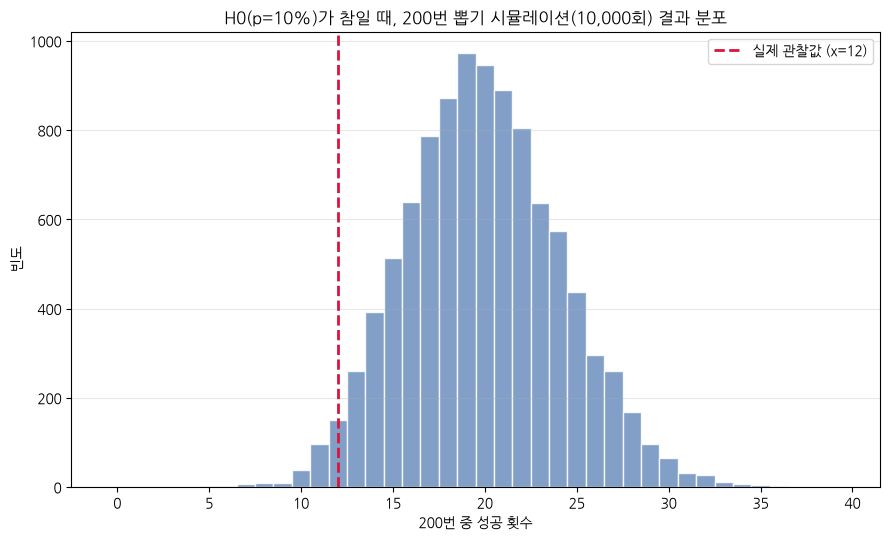

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200
p0 = 0.10
n_sim = 10000
x_observed = 12   # 실제 관찰값

simulated_successes = np.random.binomial(n=n, p=p0, size=n_sim)

plt.figure(figsize=(9, 5.5))
plt.hist(simulated_successes, bins=range(0, 41), color='#6C8EBF',
         edgecolor='white', alpha=0.85, align='left')

# 실제 관찰값(12번 성공)을 세로선으로 표시
plt.axvline(x_observed, color='crimson', linestyle='--', linewidth=2,
            label=f'실제 관찰값 (x={x_observed})')

plt.title('H0(p=10%)가 참일 때, 200번 뽑기 시뮬레이션(10,000회) 결과 분포')
plt.xlabel('200번 중 성공 횟수')
plt.ylabel('빈도')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

문제 2. 과자 한 봉지의 중량은 150g이 맞을까?

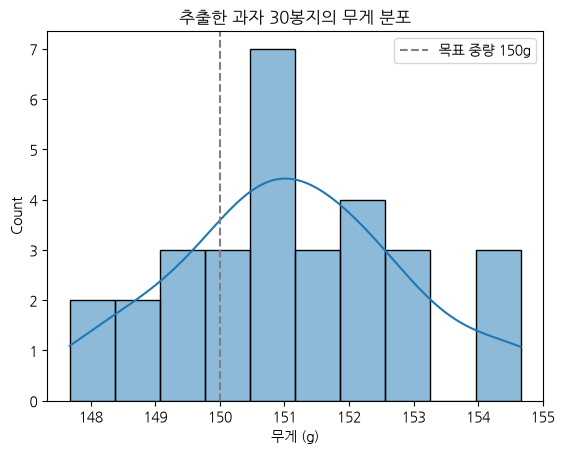

In [9]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

2-1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 과자 한 봉지의 평균 중량은 150g이다. (모평균 μ = 150)
# H₁ (대립가설): 과자 한 봉지의 평균 중량은 150g이 아니다. (모평균 μ ≠ 150)

2-2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

In [10]:
import numpy as np
from scipy import stats

np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150

# 일표본 t-검정 (양측검정, H1: μ ≠ 150)
t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)

print(f"표본 평균: {sample_weights.mean():.4f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

표본 평균: 151.1237
t-통계량: 3.4193
p-value: 0.001883


2-3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다. ( alpha = 0.05 )

In [11]:
import numpy as np
from scipy import stats

np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150
alpha = 0.05  # 유의수준

t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)

print(f"표본 평균: {sample_weights.mean():.4f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"유의수준(alpha): {alpha}")

# 통계적 결론 도출
if p_value < alpha:
    print("결론: p-value < alpha → 귀무가설(H0: μ=150)을 기각한다.")
    print("→ 과자 한 봉지의 평균 중량은 150g이 아니라고 통계적으로 유의미하게 판단된다.")
else:
    print("결론: p-value >= alpha → 귀무가설을 기각할 수 없다.")
    print("→ 평균 중량이 150g과 다르다고 볼 충분한 통계적 근거가 없다.")

표본 평균: 151.1237
t-통계량: 3.4193
p-value: 0.001883
유의수준(alpha): 0.05
결론: p-value < alpha → 귀무가설(H0: μ=150)을 기각한다.
→ 과자 한 봉지의 평균 중량은 150g이 아니라고 통계적으로 유의미하게 판단된다.


Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아 각 표본의 평균을 리스트에 저장해봅시다.
/ 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.


In [12]:
import numpy as np

np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150
sample_std = sample_weights.std(ddof=1)  # 우리가 가진 표본의 표준편차를 사용

n = 30          # 표본 크기 (한 번에 뽑는 봉지 수)
n_sim = 10000   # 반복 횟수

sample_means = []  # 각 반복의 표본 평균을 저장할 리스트

for _ in range(n_sim):
    # H0가 참(모평균=150)이라고 가정하고, 표본표준편차를 이용해 30개짜리 표본 생성
    sample = np.random.normal(loc=pop_mean, scale=sample_std, size=n)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print(f"사용한 표본표준편차: {sample_std:.4f}")
print(f"시뮬레이션된 표본평균들의 평균: {sample_means.mean():.4f}")
print(f"시뮬레이션된 표본평균들의 표준편차: {sample_means.std():.4f}")

사용한 표본표준편차: 1.8000
시뮬레이션된 표본평균들의 평균: 150.0003
시뮬레이션된 표본평균들의 표준편차: 0.3316


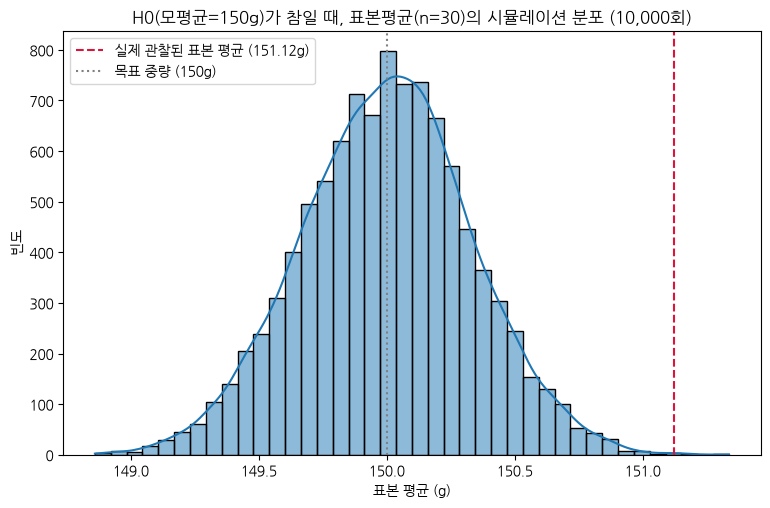

In [13]:
# 2-5. Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150
sample_std = sample_weights.std(ddof=1)
observed_mean = sample_weights.mean()

n = 30
n_sim = 10000
sample_means = []
for _ in range(n_sim):
    sample = np.random.normal(loc=pop_mean, scale=sample_std, size=n)
    sample_means.append(sample.mean())
sample_means = np.array(sample_means)

plt.figure(figsize=(9, 5.5))
sns.histplot(sample_means, bins=40, kde=True)
plt.axvline(x=observed_mean, color='crimson', linestyle='--',
            label=f'실제 관찰된 표본 평균 ({observed_mean:.2f}g)')
plt.axvline(x=pop_mean, color='gray', linestyle=':',
            label=f'목표 중량 ({pop_mean}g)')
plt.title("H0(모평균=150g)가 참일 때, 표본평균(n=30)의 시뮬레이션 분포 (10,000회)")
plt.xlabel("표본 평균 (g)")
plt.ylabel("빈도")
plt.legend()
plt.show()

1. Q5의 히스토그램은 무엇을 나타내나요? 왜 정규분포와 비슷한 모양일까요?

이 히스토그램은 **"모평균이 정확히 150g이다"라는 귀무가설이 참이라고 가정했을 때, 30개짜리 표본을 뽑을 때마다 얻을 수 있는 표본 평균들의 분포(표집분포)**를 나타냅니다.

이 분포가 종 모양(정규분포 형태)을 띠는 이유가 바로 **중심극한정리(Central Limit Theorem, CLT)**입니다.

원래 개별 과자 무게의 분포가 정규분포든 아니든 상관없이, 표본의 크기(n)가 충분히 크면(보통 n≥30) 표본 평균들의 분포는 정규분포에 가까워진다는 것이 중심극한정리의 핵심 내용입니다.

이번 문제에서는 애초에 개별 과자 무게 자체를 정규분포(np.random.normal)로 생성했기 때문에 표본 평균의 분포도 자연스럽게 정규분포를 따르지만, 설령 원래 분포가 정규분포가 아니었더라도(예: 한쪽으로 치우친 분포) n=30 정도면 표본 평균의 분포는 여전히 종 모양에 가까워집니다. 이 덕분에 우리는 t-검정처럼 정규분포(또는 t-분포) 기반의 이론적 검정을 사용할 수 있는 것입니다.

2. 관찰된 표본 평균은 흔한 값인가요? p-값과의 관계는?

흔하지 않은, 매우 드문 값입니다. 그래프에서 빨간 세로선(151.12g)은 분포의 오른쪽 꼬리 끝, 대부분의 막대가 이미 다 사라진 지점에 위치합니다.

시각적 위치 = p-value: p-value는 정확히 "이 세로선을 기준으로 그보다 더 극단적인(양쪽으로, 150g에서 더 멀리 떨어진) 영역이 전체 분포에서 차지하는 비율"입니다. 그래프에서 눈으로 봐도 세로선 오른쪽(그리고 대칭적으로 왼쪽 149g 아래 대응 지점)에 남은 막대가 거의 없다는 것 자체가 "p-value가 매우 작다"는 것을 시각적으로 보여주는 것입니다.

3. p-값이 0.001이었다면 세로선은 어디쯤일까요?

p-값이 작을수록 세로선은 분포의 중심(150g)에서 더 멀리, 꼬리의 더 깊숙한 곳에 위치하게 됩니다.

지금 시뮬레이션 기준 p-value가 약 0.0006이고 실제 세로선이 이미 분포 바깥쪽 꼬리 끝에 있으므로, p-value가 0.001이라면 지금보다 아주 약간 더 중심 쪽으로 가까운 위치(즉 지금 세로선보다 살짝 왼쪽)에 있을 것으로 예상됩니다. 두 값이 워낙 작아서 그래프상에서는 육안으로 거의 구분되지 않을 정도로 비슷한 위치일 것입니다. 반대로 p-value가 0.05였다면, 세로선은 지금보다 분포 중심에 훨씬 더 가까운 곳(대략 표준오차 2배 정도 떨어진 지점)에 위치했을 것입니다.

4. 공장 입장에서 어떤 조치가 필요할까요?

통계적 결론: 이 공정은 목표 중량(150g)보다 유의미하게 무겁게(평균 약 1.12g 초과) 생산되고 있습니다. 이는 단순한 우연이 아니라 공정 설정 자체의 문제(예: 충전 기계의 세팅값이 미세하게 어긋나 있음)일 가능성이 높습니다.

목표보다 무겁게 나오는 것의 손실:

원가 손실: 봉지 하나당 여분으로 들어가는 내용물(약 1.12g)이 전체 생산량에 걸쳐 누적되면 상당한 원재료 낭비로 이어집니다. 예를 들어 하루 10만 봉지를 생산한다면 매일 약 112kg의 원료가 "공짜로" 더 들어가는 셈입니다.
표시 중량과의 괴리: 오히려 무겁게 나오는 것은 소비자 클레임(부족량 신고) 위험은 낮추지만, 회사 입장에서는 불필요한 비용 증가로 직결됩니다.
(참고로 만약 반대로 가볍게 나왔다면 소비자 신뢰 저하, 계량법 위반 등의 리스크가 있었을 것입니다.)

조치 방향: 충전 설비(filling machine)의 세팅값을 재조정하여 평균이 정확히 150g에 가깝도록 캘리브레이션하고, 이후 지속적인 표본 검사(관리도, control chart)를 통해 공정이 목표치를 벗어나지 않는지 모니터링하는 것이 필요합니다.

문제 3. 어떤 온라인 학습 방식이 더 효과적일까?

3-1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.

H₀: 데이터는 정규분포를 따른다.

In [14]:
import numpy as np
from scipy import stats

np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

# H0: 데이터는 정규분포를 따른다
sh_a = stats.shapiro(group_a_scores)
sh_b = stats.shapiro(group_b_scores)

print(f"A그룹 - statistic: {sh_a.statistic:.4f}, p-value: {sh_a.pvalue:.4f}")
print(f"B그룹 - statistic: {sh_b.statistic:.4f}, p-value: {sh_b.pvalue:.4f}")

A그룹 - statistic: 0.9876, p-value: 0.8766
B그룹 - statistic: 0.9866, p-value: 0.8366


A그룹 p-value = 0.8766 → p > 0.05 → H₀ 기각 못함 → 정규분포를 따른다고 볼 수 있음

B그룹 p-value = 0.8366 → p > 0.05 → H₀ 기각 못함 → 정규분포를 따른다고 볼 수 있음

3-2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.

H₀: 두 그룹의 분산은 같다.

In [15]:
from scipy import stats

# H0: 두 그룹의 분산은 같다
lev = stats.levene(group_a_scores, group_b_scores)

print(f"statistic: {lev.statistic:.4f}, p-value: {lev.pvalue:.4f}")

statistic: 6.1330, p-value: 0.0150


3-3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.

등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

In [16]:
from scipy import stats

# H0: 두 그룹의 평균은 같다 / H1: 두 그룹의 평균은 다르다
# 등분산 가정이 기각되었으므로 equal_var=False (Welch's t-test)
t_res = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=False)

print(f"t-statistic: {t_res.statistic:.4f}")
print(f"p-value: {t_res.pvalue:.6f}")

t-statistic: 4.0426
p-value: 0.000115


3-4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.

두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와

나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.

힌트: np.random.permutation 을 사용해보세요.

In [17]:
import numpy as np

# 두 그룹 데이터를 하나로 합침
all_scores = np.concatenate([group_a_scores, group_b_scores])
n_a = len(group_a_scores)  # 50

np.random.seed(42)
n_sim = 10000
diff_list = []

for i in range(n_sim):
    # H0가 사실이라면 A/B 라벨은 의미가 없으므로, 무작위로 섞어서 다시 나눈다
    shuffled = np.random.permutation(all_scores)
    sim_a = shuffled[:n_a]      # 가상 A그룹 (50개)
    sim_b = shuffled[n_a:]      # 가상 B그룹 (나머지 50개)
    diff_list.append(sim_a.mean() - sim_b.mean())

diff_list = np.array(diff_list)

생성된 시뮬레이션 개수: 10000

평균: -0.0161

표준편차: 1.6559

최소/최대: -6.1413 / 6.5129

3-5.  Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.

실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

6.271076867213665


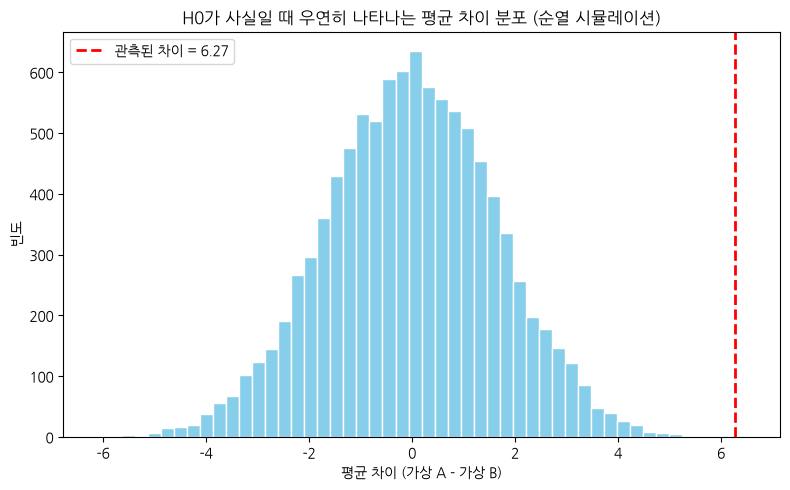

In [20]:
# 실제 관찰된 두 그룹의 평균 차이 계산
observed_diff = group_a_scores.mean() - group_b_scores.mean()
print(observed_diff)  # 6.271...

import matplotlib.pyplot as plt

observed_diff = group_a_scores.mean() - group_b_scores.mean()

plt.figure(figsize=(8, 5))
plt.hist(diff_list, bins=50, color='skyblue', edgecolor='white')
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2,
            label=f'관측된 차이 = {observed_diff:.2f}')
plt.title('H0가 사실일 때 우연히 나타나는 평균 차이 분포 (순열 시뮬레이션)')
plt.xlabel('평균 차이 (가상 A - 가상 B)')
plt.ylabel('빈도')
plt.legend()
plt.tight_layout()
plt.show()

1. 정규성·등분산성 검정의 p-값 해석, 그리고 t-검정 사용에 문제가 없는가?

정규성 검정 (Shapiro-Wilk):

A그룹 p=0.8766, B그룹 p=0.8366 → 둘 다 p > 0.05이므로 H₀("정규분포를 따른다")를 기각하지 못합니다. 즉 "정규분포가 아니라는 증거를 찾지 못했다"는 뜻이고, 정규성 가정은 문제없이 충족됩니다.

등분산성 검정 (Levene):

p=0.0150 < 0.05 → H₀("두 그룹의 분산은 같다")를 기각합니다. 즉 두 그룹의 분산이 다르다는 증거가 있습니다.

t-검정 사용에 문제가 없는가? — 여기서 중요한 건 "문제가 없다"를 어떻게 정의하느냐입니다.

정규성은 만족했으니 t-검정의 기본 전제(각 그룹이 정규분포) 자체는 문제없습니다.
하지만 등분산은 만족하지 못했으므로, 일반 Student's t-test(등분산 가정)를 그대로 쓰면 안 됩니다. 대신 등분산을 가정하지 않는 Welch's t-test(equal_var=False)를 쓰면 이 문제를 해결할 수 있습니다. 실제로 우리가 Q3에서 이미 그렇게 처리했죠.

즉 "가정이 다 깨졌으니 t-검정을 쓸 수 없다"가 아니라, **"가정 충족 여부에 맞춰 올바른 버전의 t-검정을 골라 썼기 때문에 문제없다"**가 정확한 결론입니다.

2. Q5 히스토그램의 중심이 0에 가까운 이유

시뮬레이션은 "A/B 라벨을 무작위로 섞는다"는 절차로 만들어졌습니다. 즉 매 반복마다 100개의 점수를 완전히 무작위로 50개/50개로 쪼갠 것이므로, 가상 A그룹과 가상 B그룹은 사실 같은 모집단(전체 100개 점수)에서 무작위로 뽑힌 표본일 뿐입니다.

이렇게 라벨의 의미가 사라진 상태에서는 두 그룹 평균이 체계적으로 한쪽으로 쏠릴 이유가 없으므로, 평균 차이는 0을 중심으로 좌우 대칭에 가깝게 분포하게 됩니다. 이는 정확히 "H₀(두 방식의 효과가 같다)가 사실이라면 어떤 일이 벌어질지"를 시뮬레이션한 것이므로, 중심이 0 근처인 게 당연한 결과입니다.

3. 관측된 평균 차이는 우연의 범위 안인가, 밖인가?

벗어납니다. 관측된 차이는 6.27점인데, 시뮬레이션 분포의 대부분은 -5 ~ +5 범위 안에 몰려 있고, 95% 구간은 대략 [-3.29, 3.29] 수준입니다. 6.27은 이 분포의 오른쪽 꼬리 바깥, 거의 끝자락에 위치합니다.

4. 이 시각적 판단과 Q3의 p-값의 관계

둘은 사실 같은 질문에 대한 서로 다른 접근 방식입니다.

순열 시뮬레이션의 p-value는 "10,000번 중 |차이| ≥ 6.27이 나온 비율"이고, 계산해보면 약 0.0001입니다.
Welch's t-test의 p-value는 이론적 분포(t분포)를 이용해 계산한 값으로 0.000115였습니다.

두 값이 거의 똑같죠. 히스토그램에서 "세로선이 분포 바깥에 있다"는 시각적 판단은 곧 "이 정도로 극단적인 값이 우연히 나올 확률이 매우 낮다"는 뜻이고, 이것이 바로 p-value가 작다는 것의 의미입니다. 즉 t-검정의 p-value는 이 시뮬레이션이 실제로 보여주는 것을 수식으로 미리 계산해 놓은 것이라고 이해하면 됩니다. 이론(t-검정)과 리샘플링(시뮬레이션)이라는 서로 다른 방법이 같은 결론에 도달했다는 점이 이 실습의 핵심 메시지입니다.

5. 교육 기업은 이 결과를 어떻게 활용할 수 있을까?

통계적으로 유의미하다는 것이 확인되었으니(우연이라고 보기 어려운 평균 6.27점 차이), 다음과 같은 의사결정에 근거로 쓸 수 있습니다.

자원 재배분: B방식보다 A방식에 콘텐츠 개발·마케팅 예산을 더 투입하거나, 신규 학생에게 A방식을 기본으로 안내
B방식 개선 또는 단계적 폐지: B방식이 왜 덜 효과적인지 원인 분석(콘텐츠 난이도, 학습 몰입도 설계 등) 후 개선하거나, 개선이 어렵다면 A방식으로 통합
후속 검증: 이번 결과는 "1개월, 특정 학생군" 기준입니다. 다른 과목/학년/기간에도 같은 효과가 재현되는지 추가 실험(A/B 테스트)으로 확인 필요
효과 크기도 함께 보고: p-value는 "우연이 아니다"는 것만 말해줄 뿐, "얼마나 실질적으로 중요한 차이인가"는 따로 봐야 합니다. 6.27점 차이가 실제 학습 성과(자격증 합격률, 취업 연계율 등) 관점에서 의미 있는 수준인지 비즈니스 맥락에서 추가로 판단해야 합니다.